# Install Data and relevant packages

In [66]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np


In [67]:
pd.set_option('display.precision', 3)

In [68]:
sns.set_style("whitegrid")
sns.set_palette("colorblind")

In [69]:
# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-prediction-dataset


In [70]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]


# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "iammustafatz/diabetes-prediction-dataset",
  "diabetes_prediction_dataset.csv",
)

df

/tmp/ipython-input-3226034346.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


# Data Cleaning and Preprocessing

In [71]:
df.isna().any()

,0
gender,False
age,False
hypertension,False
heart_disease,False
smoking_history,False
bmi,False
HbA1c_level,False
blood_glucose_level,False
diabetes,False


Examine categorial data

In [72]:
df['gender'].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


In [73]:
df['hypertension'].value_counts()

,count
hypertension,
0,92515
1,7485


In [74]:
df['heart_disease'].value_counts()

,count
heart_disease,
0,96058
1,3942


In [75]:
df['smoking_history'].value_counts()

,count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


In [76]:
df['diabetes'].value_counts() #imbalance data

,count
diabetes,
0,91500
1,8500


In [77]:
#remove other in gender
df = df[df['gender'] != 'Other']

No Info smoking history relvancy

In [78]:
#patience/all only no info
df_no_info = df[df['smoking_history'] == 'No Info']
print(f'ratio of diabetes patient to all patient for people without smoking info: {df_no_info['diabetes'].sum()/len(df_no_info)}')
#patience/all for all
print(f'ratio of diabetes patient to all patient: {df['diabetes'].sum()/len(df)}')

ratio of diabetes patient to all patient for people without smoking info: 0.040603183468304944
ratio of diabetes patient to all patient: 0.08501530275449581


Text(0.5, 1.0, 'Composition of Smoking Habits Count for each Age Groups')

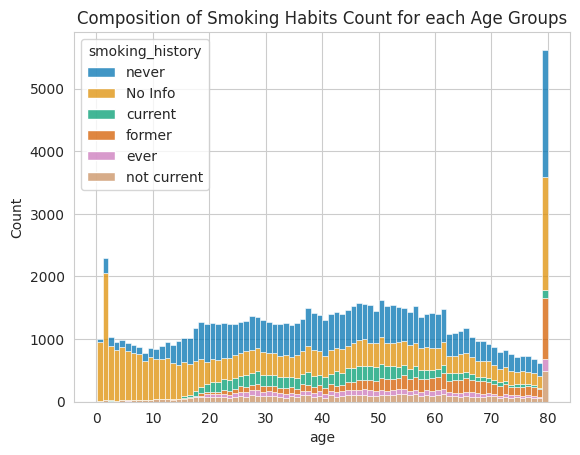

In [79]:
sns.histplot(data=df, x='age', hue='smoking_history', bins=80, multiple='stack')
plt.title('Composition of Smoking Habits Count for each Age Groups')

#plt.savefig('file.jpg', dpi=300)

Text(0.5, 1.0, 'Relationship of Age and Diabetic Risks for Different Smoking Habits')

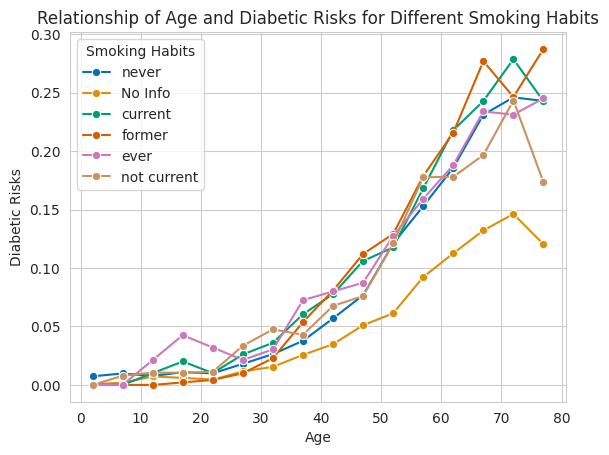

In [80]:
hues  = []
x = [i*5+2 for i in range(16)]

diseases = 'diabetes'
for i, smoking_history in enumerate(df['smoking_history'].unique()):

  percentages = []
  for age in range(16):

    df_age = df[(df['age'] >= age*5) & (df['age'] <= age*5+4)]
    total = len(df_age[df_age['smoking_history'] == smoking_history])

    if total <= 40:
      percentages.append(0)
    else:
      percentages.append(df_age[df_age['smoking_history'] == smoking_history][diseases].sum()/total)
  for i, p in enumerate(percentages):
    if p == 0 and 0 < i < len(percentages)-1:
      percentages[i] = (percentages[i-1] + percentages[i+1])/2
  sns.lineplot(x=x, y=percentages, label=smoking_history, marker='o')

plt.ylabel('Diabetic Risks')
plt.xlabel('Age')
plt.legend(title='Smoking Habits')
plt.title('Relationship of Age and Diabetic Risks for Different Smoking Habits')


In [81]:
df[(df['smoking_history'] == 'current')].sort_values(by='age').head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
54981,Male,0.32,0,0,current,15.17,4.0,100,0
98434,Female,1.40,0,0,current,19.53,5.8,80,0
72369,Female,1.48,0,0,current,16.95,4.5,200,0
36249,Male,1.48,0,0,current,17.48,3.5,140,0
82586,Female,1.80,0,0,current,18.68,6.0,126,0
61182,Female,2.00,0,0,current,16.89,6.6,155,0
71094,Male,2.00,0,0,current,16.21,5.7,85,0
65482,Female,2.00,0,0,current,16.63,6.6,100,0
21911,Male,2.00,0,0,current,15.87,5.7,130,0
75620,Female,2.00,0,0,current,17.97,5.7,130,0


In [82]:
#patient with age under 13(teenager start at 13) is unlikely to have type II diabetes and smoking history of young patients is improbable to be true
#remove patient under age 13

df = df[df['age'] >= 13]

In [83]:
#relabel not current and ever as former smoker
df.loc[df['smoking_history'] == 'not current', 'smoking_history'] = 'former'
df.loc[df['smoking_history'] == 'ever', 'smoking_history'] = 'former'

# Exploratory Data Analysis

distribution of continuous variable

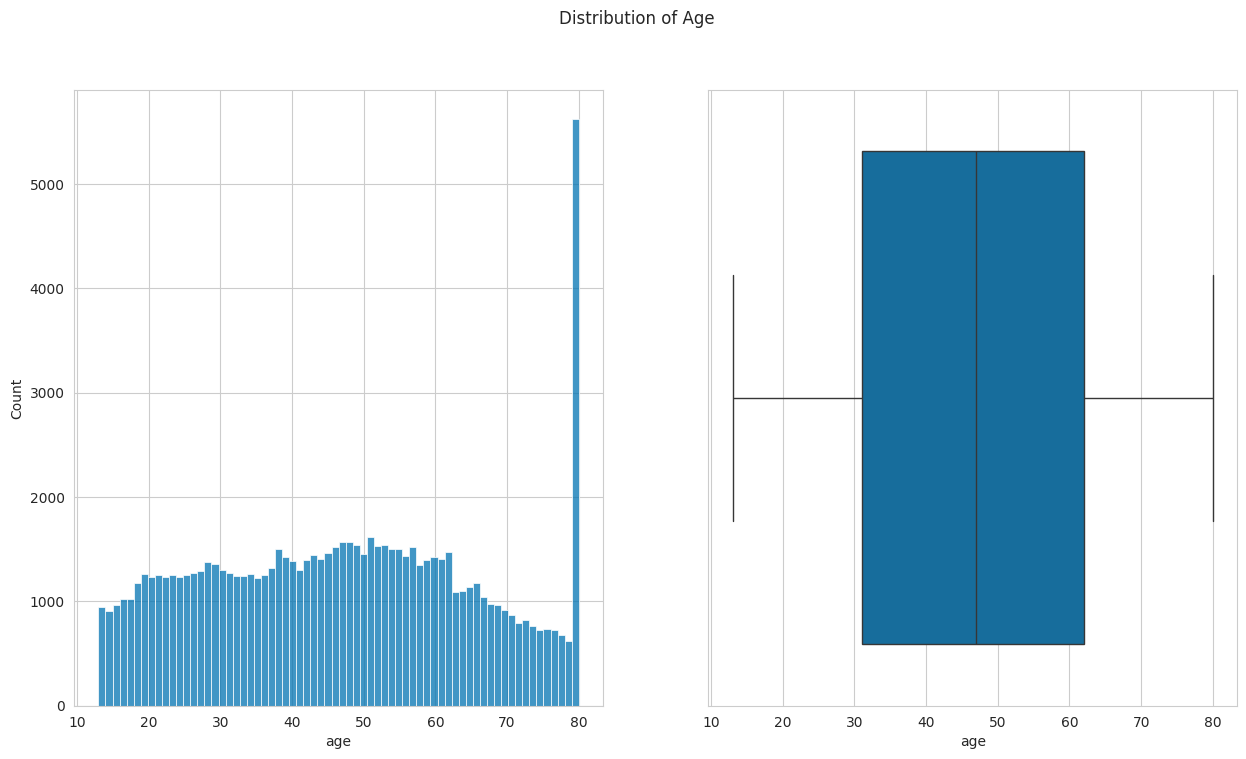

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

sns.histplot(data=df, x='age', bins=68, ax=ax[0])
sns.boxplot(data=df, x='age', ax=ax[1])
fig.suptitle('Distribution of Age')
plt.show()

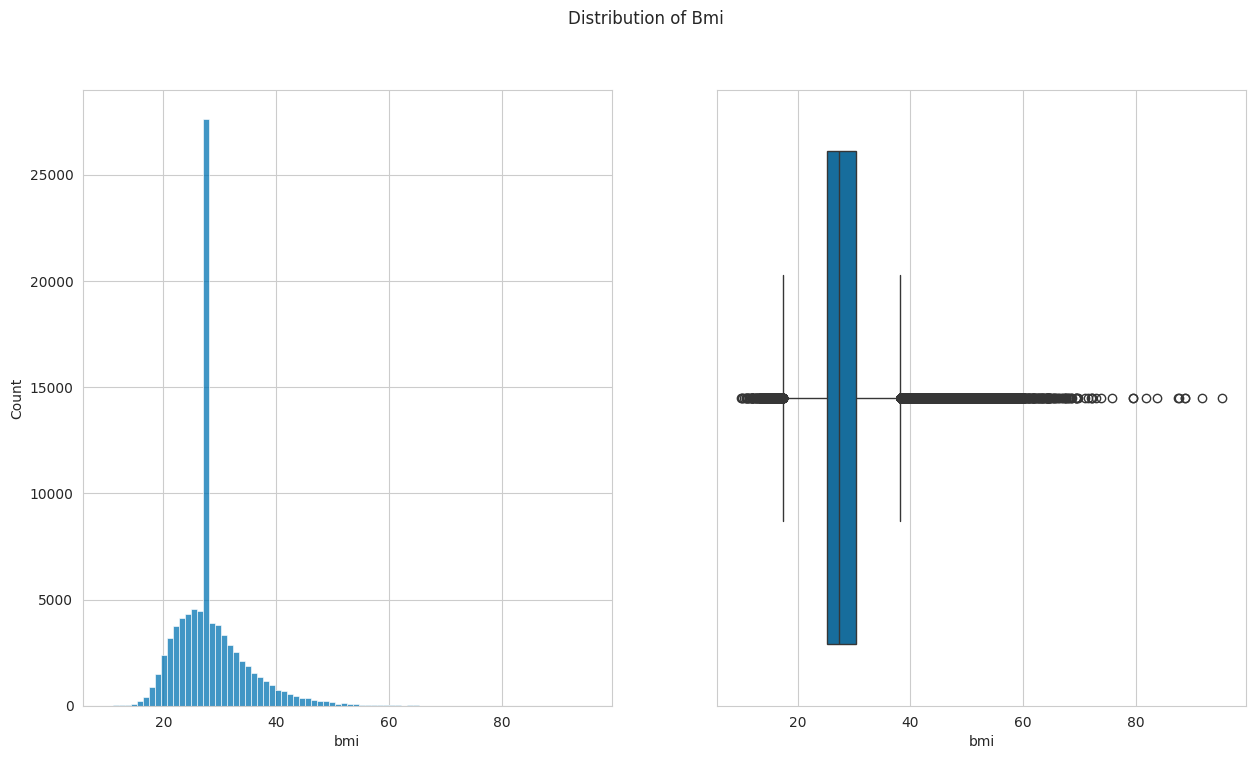

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

sns.histplot(data=df, x='bmi', bins=80, ax=ax[0])
sns.boxplot(data=df, x='bmi', ax=ax[1])
fig.suptitle('Distribution of Bmi')
plt.show()

examine age and bmi distribution

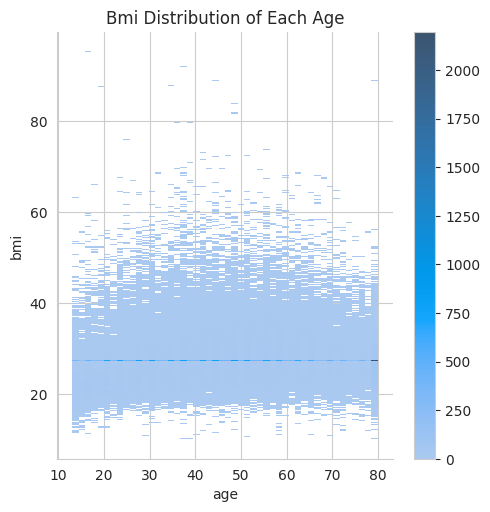

In [86]:
sns.displot(data=df, x='age', y='bmi', cbar=True).set(title='Bmi Distribution of Each Age')
#Bmi is evenly distributed for all ages

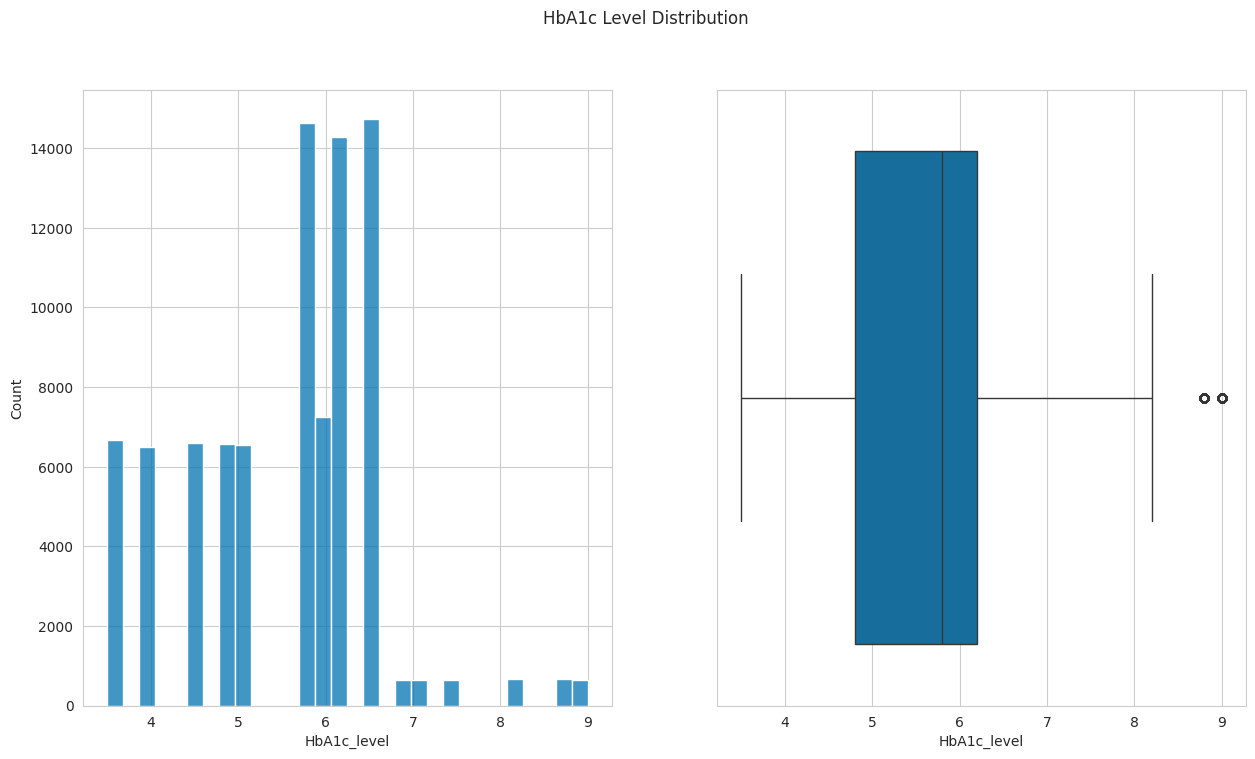

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

sns.histplot(data=df, x='HbA1c_level', bins=30, ax=ax[0])
sns.boxplot(data=df, x='HbA1c_level', ax=ax[1])
fig.suptitle('HbA1c Level Distribution')
plt.show()

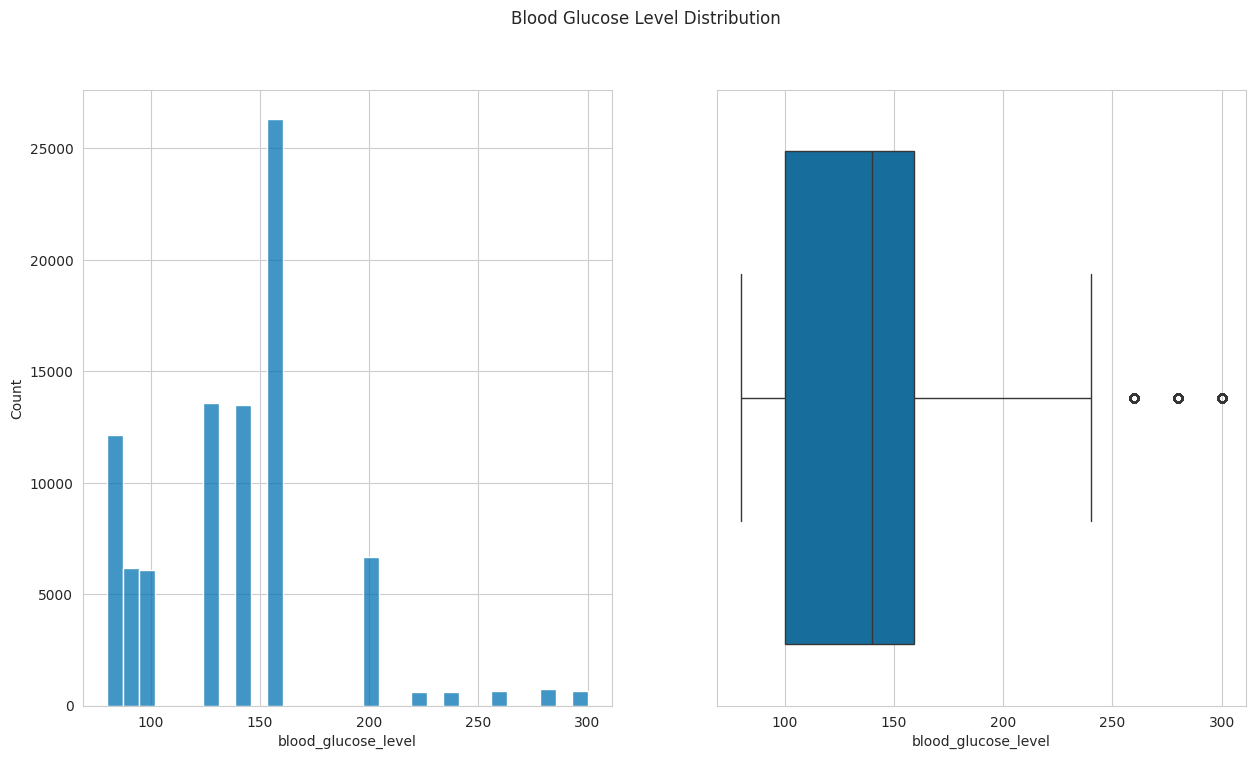

In [88]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

sns.histplot(data=df, x='blood_glucose_level', bins=30, ax=ax[0])
sns.boxplot(data=df, x='blood_glucose_level', ax=ax[1])
fig.suptitle('Blood Glucose Level Distribution')
plt.show()


Examine categorical variable

In [89]:
df['diabetes'].value_counts()

,count
diabetes,
0,79166
1,8464


In [90]:
df['hypertension'].value_counts()

,count
hypertension,
0,80149
1,7481


In [91]:
df['heart_disease'].value_counts()

,count
heart_disease,
0,83693
1,3937


In [92]:
df['gender'].value_counts()

,count
gender,
Female,52569
Male,35061


In [93]:
df['smoking_history'].value_counts()

,count
smoking_history,
never,33430
No Info,25453
former,19488
current,9259


In [94]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


[Text(0.5, 1.0, 'Correlation Between Numerical Variables')]

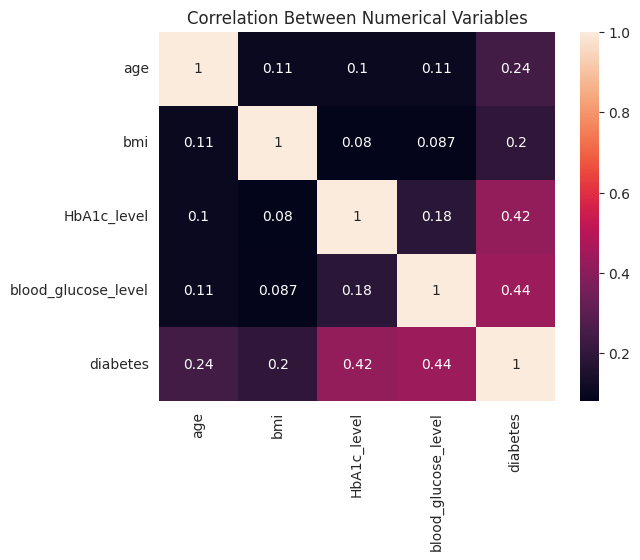

In [95]:
corr = df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']].corr()
sns.heatmap(corr, annot=True).set(title='Correlation Between Numerical Variables')

view blood_glucose_level and diabetes risk relationship

plot blood_glucose_level and diabetes risk

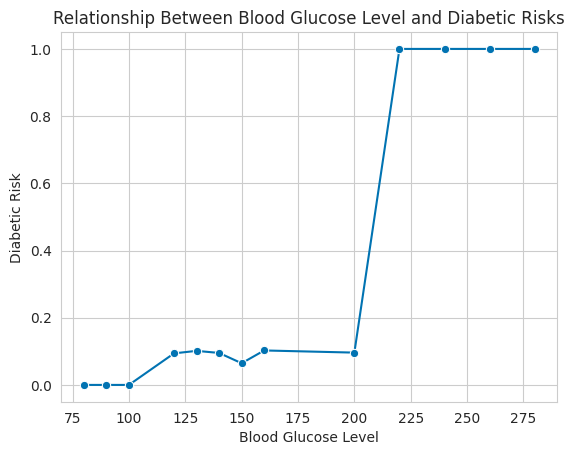

In [96]:
x_var = 'blood_glucose_level'
step = 10
x_range = range(df[x_var].min(), df[x_var].max(), step)
x_plot = []
percentages = []

for x in x_range:

  df_group = df[(df[x_var] >= x) & (df[x_var] < x+step)]
  total = len(df_group)

  if total <= 40:
    pass
  else:
    x_plot.append(x)
    percentages.append(df_group['diabetes'].sum()/total)

sns.lineplot(x=x_plot, y=percentages, marker='o')
plt.ylabel('Diabetic Risk')
plt.xlabel('Blood Glucose Level')
plt.title('Relationship Between Blood Glucose Level and Diabetic Risks')
plt.show()



plot HbA1C and diabetes risk

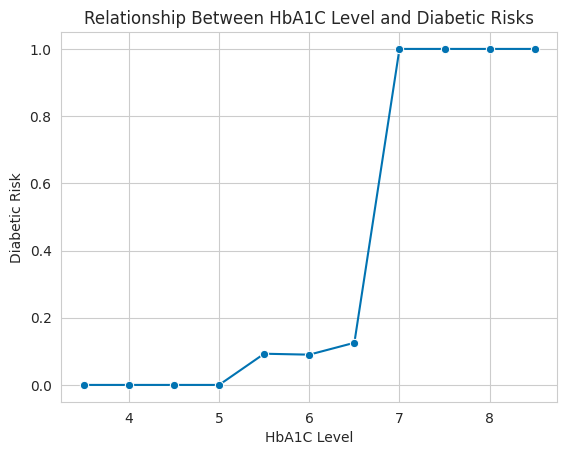

In [97]:
x_var = 'HbA1c_level'
step = 0.5
x_range = np.arange(math.floor(df[x_var].min()), math.ceil(df[x_var].max()), step)
x_plot = []
percentages = []
for x in x_range:

  df_group = df[(df[x_var] >= x) & (df[x_var] < x+step)]
  total = len(df_group)

  if total <= 40:
    pass
  else:
    x_plot.append(x)
    percentages.append(df_group['diabetes'].sum()/total)

sns.lineplot(x=x_plot, y=percentages, marker='o')
plt.ylabel('Diabetic Risk')
plt.xlabel('HbA1C Level')
plt.title('Relationship Between HbA1C Level and Diabetic Risks')
plt.show()


compare different smoking group with diabetes risks

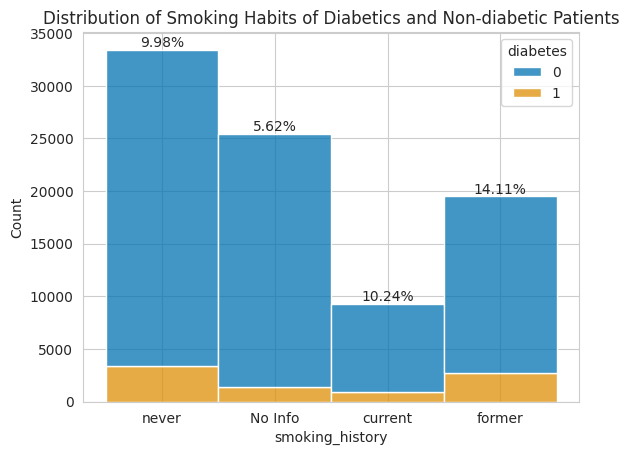

In [98]:
ax = sns.histplot(data=df, x='smoking_history', hue='diabetes', multiple='stack')
ax.bar_label(ax.containers[1], labels=[f'{d/(d+normal)*100:.2f}%' for d, normal in zip(ax.containers[0].datavalues, ax.containers[1].datavalues)])
ax.set(title='Distribution of Smoking Habits of Diabetics and Non-diabetic Patients')
plt.show()

compare bmi on diabetes and normal people

[Text(0.5, 1.0, 'Comparison of Bmi Between Diabetic and Non-diabetic Patient')]

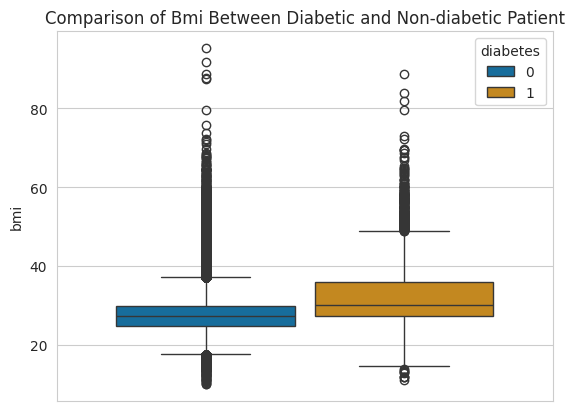

In [99]:
sns.boxplot(data=df, y='bmi', hue='diabetes', gap=0.1).set(title='Comparison of Bmi Between Diabetic and Non-diabetic Patient')

compare age on diabetes/non diabetes

[Text(0.5, 1.0, 'Comparison of Age Between Diabetic and Non-diabetic Patient')]

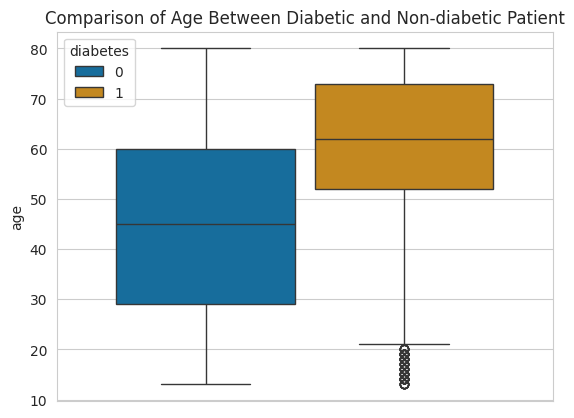

In [100]:
sns.boxplot(data=df, y='age', hue='diabetes', gap=0.1).set(title='Comparison of Age Between Diabetic and Non-diabetic Patient')

# Descriptive Statistics

In [101]:
df.describe().loc[['mean', 'std', '25%', '50%', '75%']]

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
mean,46.983,0.085,0.045,28.390,5.543,138.780,0.097
std,19.145,0.279,0.207,6.112,1.082,41.474,0.295
25%,31.000,0.000,0.000,25.180,4.800,100.000,0.000
50%,47.000,0.000,0.000,27.320,5.800,140.000,0.000
75%,62.000,0.000,0.000,30.410,6.200,159.000,0.000


In [102]:
df['gender'].value_counts()

,count
gender,
Female,52569
Male,35061


In [103]:
df['diabetes'].value_counts()

,count
diabetes,
0,79166
1,8464


In [104]:
df['heart_disease'].value_counts()

,count
heart_disease,
0,83693
1,3937


In [105]:
df['hypertension'].value_counts()

,count
hypertension,
0,80149
1,7481


In [106]:
df['smoking_history'].value_counts()

,count
smoking_history,
never,33430
No Info,25453
former,19488
current,9259


# Inference

do having heart disease significantly increase risk of having diabetes

In [107]:
matrix = [[0, 0], [0, 0]]

for i in range(2):
  for j in range(2):
    matrix[i][j] = len(df[(df['heart_disease']==i) & (df['diabetes']==j)])

In [108]:
matrix

[[76495, 7198], [2671, 1266]]

In [109]:
#H0: p(diabetes|heart disease) - p(diabetes) <= 0
#H1: p(diabetes|heart disease) - p(diabetes) > 0

p_diabetes = (matrix[0][1] + matrix[1][1])/(sum(matrix[0]) + sum(matrix[1]))
p_diabetes_g_heart = (matrix[1][1])/(matrix[1][0] + matrix[1][1])

print(f'p(diabetes) = {p_diabetes}')
print(f'p(diabetses|heart disease) = {p_diabetes_g_heart}')


p(diabetes) = 0.09658792650918635
p(diabetses|heart disease) = 0.32156464312928623


In [110]:
#assume H0 is true p(diabetes|heart disease) - p(diabetes)  ~ N(0, S_p(D)**2 + S_p(D|H)**2)
#since m and n is large we can assume normal distribution instead of t distribution

n = sum(matrix[0]) + sum(matrix[1])
m = matrix[1][0] + matrix[1][1]

test_statistic_unnorm = (p_diabetes_g_heart - p_diabetes)
var_p_diabetes = ((p_diabetes)*(1-p_diabetes))/n
var_p_diabetes_g_heart = ((p_diabetes_g_heart)*(1-p_diabetes_g_heart))/m
test_statistic = test_statistic_unnorm/math.sqrt(var_p_diabetes + var_p_diabetes_g_heart)


# let alpha be 0.05
# one tail
# zalpha = 1.645

print(f'given the test statistic = {test_statistic:.4f} which fall in the critical region, we reject the null hypothesis with confidence greater 95%')



given the test statistic = 29.9547 which fall in the critical region, we reject the null hypothesis with confidence greater 95%


do people with diabetes have significantly higher bmi

In [111]:
df_stat_diabetes = df[df['diabetes'] == 1].describe()
mean_bmi_diabetes = df_stat_diabetes['bmi']['mean']
n = df_stat_diabetes['bmi']['count']
var_mean_bmi_diabetes = (df_stat_diabetes['bmi']['std'])**2/n

df_stat_diabetes

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,8464.000,8464.000,8464.000,8464.000,8464.000,8464.000,8464.0
mean,61.172,0.247,0.150,32.039,6.934,194.074,1.0
std,14.163,0.431,0.357,7.526,1.076,58.651,0.0
min,13.000,0.000,0.000,10.980,5.700,126.000,1.0
25%,52.000,0.000,0.000,27.320,6.100,145.000,1.0
50%,62.000,0.000,0.000,29.990,6.600,160.000,1.0
75%,73.000,0.000,0.000,35.953,7.500,240.000,1.0
max,80.000,1.000,1.000,88.720,9.000,300.000,1.0


In [112]:
df_stat_non_diabetes = df[df['diabetes'] == 0].describe()
mean_bmi_non_diabetes = df_stat_non_diabetes['bmi']['mean']
m = df_stat_non_diabetes['bmi']['count']
var_mean_bmi_non_diabetes = (df_stat_non_diabetes['bmi']['std'])**2/m
df_stat_non_diabetes

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,79166.000,79166.000,79166.000,79166.000,79166.000,79166.000,79166.0
mean,45.466,0.068,0.034,28.000,5.395,132.868,0.0
std,18.985,0.252,0.181,5.807,0.972,34.270,0.0
min,13.000,0.000,0.000,10.010,3.500,80.000,0.0
25%,29.000,0.000,0.000,24.880,4.800,100.000,0.0
50%,45.000,0.000,0.000,27.320,5.800,140.000,0.0
75%,60.000,0.000,0.000,29.770,6.200,158.000,0.0
max,80.000,1.000,1.000,95.220,6.600,200.000,0.0


In [113]:
#H0: mean_bmi_diabetes - mean_bmi_non_diabetes <= 0
#H1: mean_bmi_diabetes - mean_bmi_non_diabetes > 0

#assume H0 is true mean_bmi_diabetes - mean_bmi_non_diabetes ~ N(0, var_mean_bmi+var_mean_bmi_non_diabetes)

test_statistic_unnorm = mean_bmi_diabetes - mean_bmi_non_diabetes
variance = var_mean_bmi_diabetes + var_mean_bmi_non_diabetes
test_statistic = test_statistic_unnorm/math.sqrt(variance)

# let alpha be 0.05
# one tail
# zalpha = 1.645

print(f'given the test statistic = {test_statistic:.4f} which fall in the critical region, we reject the null hypothesis with confidence greater 95%')



given the test statistic = 47.8780 which fall in the critical region, we reject the null hypothesis with confidence greater 95%
